# Tech Challenge Fase 4 — LSTM para Previsão de Preços de Ações

**Pós Tech — Machine Learning Engineering**

Este notebook documenta todo o processo de desenvolvimento do modelo:

1. Coleta de dados via `yfinance`
2. Análise exploratória
3. Pré-processamento (normalização + janelamento)
4. Construção e treino da LSTM
5. Avaliação com MAE, RMSE e MAPE
6. Salvamento do modelo para deploy

## 1. Imports e configuração

In [ ]:
import os
import sys
import json
import importlib
from pathlib import Path

# PROJECT_ROOT robusto: funciona independente de onde o kernel iniciou
_cwd = Path(os.path.abspath('')).resolve()
PROJECT_ROOT = _cwd.parent if _cwd.name == 'notebooks' else _cwd
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# Purga estado corrompido do yfinance/curl_cffi do kernel antes de importar
for _mod in list(sys.modules.keys()):
    if _mod.startswith('yfinance') or 'curl_cffi' in _mod:
        del sys.modules[_mod]

try:
    import yfinance as yf
except Exception as _yf_err:
    yf = None
    print(f'AVISO: yfinance indisponível ({_yf_err}) — será usado cache CSV')

# Garante que src.data_loader usa a versão mais recente do arquivo
import src.data_loader
importlib.reload(src.data_loader)
from src.data_loader import fetch_stock_data, get_close_prices

from src.preprocessor import prepare_dataset, inverse_transform, save_scaler
from src.model import build_lstm_model, get_callbacks
from src.evaluate import compute_metrics, print_metrics

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

print('TensorFlow:', tf.__version__)
print('PROJECT_ROOT:', PROJECT_ROOT)
print('GPU disponível:', len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow: 2.17.0
PROJECT_ROOT: C:\Users\Dione\Desktop\tech-challenge-fase4\tech-challenge-fase4
GPU disponível: False


## 2. Coleta de dados

In [ ]:
SYMBOL = 'AAPL'
START_DATE = '2018-01-01'
END_DATE = '2024-07-20'

CSV_CACHE = PROJECT_ROOT / 'data' / f'{SYMBOL}_{START_DATE[:4]}_{END_DATE[:4]}.csv'

df = None

# 1. Carrega do cache CSV (independente de rede/yfinance)
if CSV_CACHE.exists():
    df = pd.read_csv(CSV_CACHE, parse_dates=['Date'])
    print(f'Cache carregado: {CSV_CACHE.name} ({len(df)} linhas)')

# 2. Fallback: tenta yfinance
if df is None or df.empty:
    try:
        df = fetch_stock_data(SYMBOL, START_DATE, END_DATE)
        print(f'Dados via fetch_stock_data: {len(df)} linhas')
    except Exception as e:
        print(f'fetch_stock_data falhou: {e}\nTentando yf.download...')
        df = yf.download(SYMBOL, start=START_DATE, end=END_DATE, progress=False)

if df is None or df.empty:
    raise ValueError(
        f"Nenhum dado retornado para '{SYMBOL}'. "
        f"Verifique o ticker e as datas ({START_DATE} a {END_DATE})."
    )

# Normaliza colunas MultiIndex (yfinance >= 1.x)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

if 'Close' not in df.columns and 'Adj Close' in df.columns:
    df = df.rename(columns={'Adj Close': 'Close'})

if 'Close' not in df.columns:
    raise ValueError(f"'Close' não encontrado: {df.columns.tolist()}")

if 'Date' in df.columns:
    df = df.set_index('Date')

if hasattr(df.index, 'tz') and df.index.tz is not None:
    df.index = df.index.tz_convert(None)

df = df.dropna(subset=['Close']).sort_index()

print(f'Dados de {SYMBOL}: {len(df)} dias úteis')
df.head()

Cache carregado: AAPL_2018_2024.csv (1647 linhas)
Dados de AAPL: 1647 dias úteis


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2018-01-02 05:00:00,39.776197,40.276438,39.565813,40.267086,102223600,0.0,0.0
2018-01-03 05:00:00,40.330191,40.802382,40.196951,40.260063,118071600,0.0,0.0
2018-01-04 05:00:00,40.332532,40.549929,40.225006,40.447075,89738400,0.0,0.0
2018-01-05 05:00:00,40.542924,40.994074,40.451758,40.907585,94640000,0.0,0.0
2018-01-08 05:00:00,40.755623,41.050156,40.657442,40.755623,82271200,0.0,0.0


In [ ]:
df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,1647.000000,1647.000000,1647.000000,1647.000000,1.647000e+03,1647.000000,1647.000000
mean,114.153367,115.423162,112.976531,114.252084,1.037180e+08,0.003332,0.002429
std,53.580217,54.096433,53.095411,53.616506,5.474690e+07,0.026480,0.098563
min,34.161698,34.574544,33.691911,33.736992,2.404830e+07,0.000000,0.000000
25%,52.602150,53.054944,52.123308,52.618731,6.764075e+07,0.000000,0.000000
50%,126.522793,127.952801,124.905188,127.166138,8.988090e+07,0.000000,0.000000
75%,160.830821,162.921273,159.396819,161.593781,1.245094e+08,0.000000,0.000000
max,234.449102,235.192661,231.088216,232.803375,4.265100e+08,0.250000,4.000000


## 3. Análise exploratória

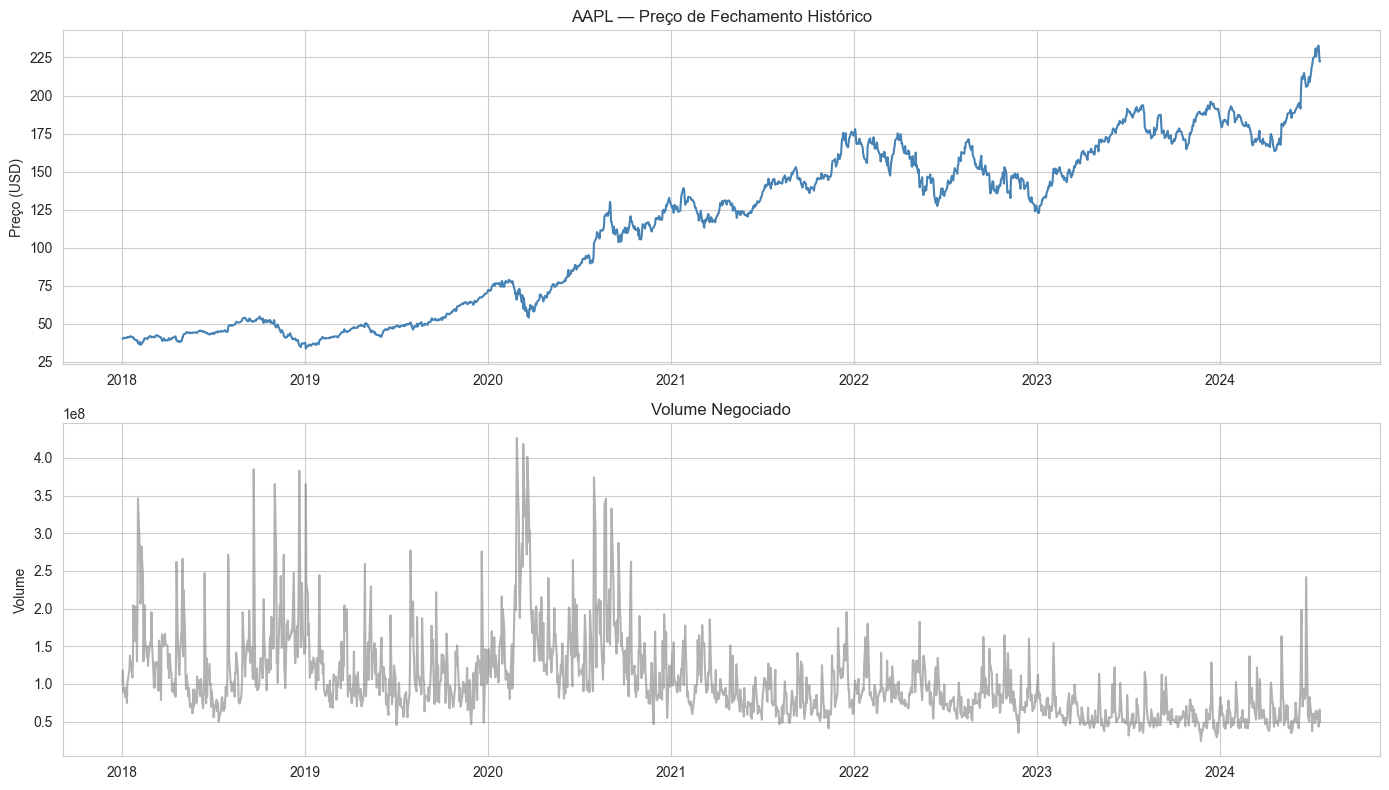

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df.index, df['Close'], color='steelblue')
axes[0].set_title(f'{SYMBOL} — Preço de Fechamento Histórico')
axes[0].set_ylabel('Preço (USD)')

axes[1].plot(df.index, df['Volume'], color='gray', alpha=0.6)
axes[1].set_title('Volume Negociado')
axes[1].set_ylabel('Volume')

plt.tight_layout()
plt.show()

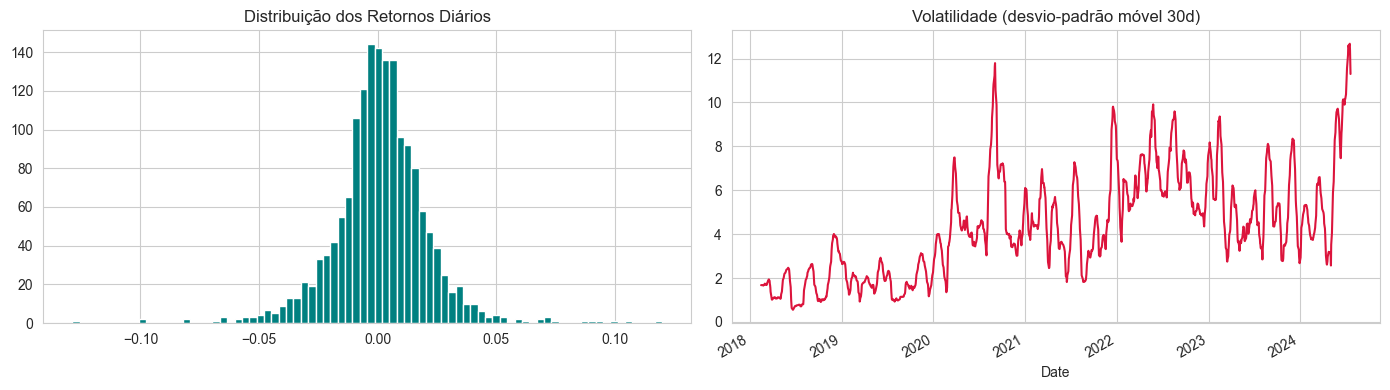

Retorno médio diário: 0.123%
Volatilidade anualizada: 31.16%


In [ ]:
# Retornos diários
df['Returns'] = df['Close'].pct_change()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['Returns'].dropna().hist(bins=80, ax=axes[0], color='teal')
axes[0].set_title('Distribuição dos Retornos Diários')

df['Close'].rolling(30).std().plot(ax=axes[1], color='crimson')
axes[1].set_title('Volatilidade (desvio-padrão móvel 30d)')
plt.tight_layout()
plt.show()

print(f'Retorno médio diário: {df["Returns"].mean()*100:.3f}%')
print(f'Volatilidade anualizada: {df["Returns"].std()*np.sqrt(252)*100:.2f}%')

## 4. Pré-processamento

In [ ]:
WINDOW_SIZE = 60
TRAIN_RATIO = 0.8

closes = get_close_prices(df)

if closes.empty:
    raise ValueError(
        f"Nenhum dado de fechamento disponível para '{SYMBOL}'. "
        "Verifique a coleta de dados e as datas fornecidas."
    )

if len(closes) <= WINDOW_SIZE:
    raise ValueError(
        f"Número de amostras ({len(closes)}) insuficiente para janela de {WINDOW_SIZE} dias."
    )

X_train, X_test, y_train, y_test, scaler = prepare_dataset(
    closes,
    window_size=WINDOW_SIZE,
    train_ratio=TRAIN_RATIO,
)

print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_test : {X_test.shape} | y_test : {y_test.shape}')

X_train: (1269, 60, 1) | y_train: (1269,)
X_test : (318, 60, 1) | y_test : (318,)


## 5. Construção e treinamento da LSTM

In [ ]:
model = build_lstm_model(
    window_size=WINDOW_SIZE,
    lstm_units_1=64,
    lstm_units_2=64,
    dropout_rate=0.2,
    learning_rate=0.001,
)
model.summary()

Model: "lstm_stock_predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,033 (203.25 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = list(get_callbacks(patience=10))

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    shuffle=False,
    verbose=1,
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - loss: 0.0048 - mae: 0.0573 - val_loss: 0.0043 - val_mae: 0.0519 - learning_rate: 2.5000e-04
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 137ms/step - loss: 0.0028 - mae: 0.0381 - val_loss: 0.0070 - val_mae: 0.0717 - learning_rate: 2.5000e-04
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - loss: 0.0029 - mae: 0.0383 - val_loss: 0.0065 - val_mae: 0.0684 - learning_rate: 2.5000e-04
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 186ms/step - loss: 0.0024 - mae: 0.0352 - val_loss: 0.0090 - val_mae: 0.0839 - learning_rate: 2.5000e-04
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 137ms/step - loss: 0.0027 - mae: 0.0367 - val_loss: 0.0108 - val_mae: 0.0936 - learning_rate: 2.5000e-04
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.0010 - mae: 0.0216    

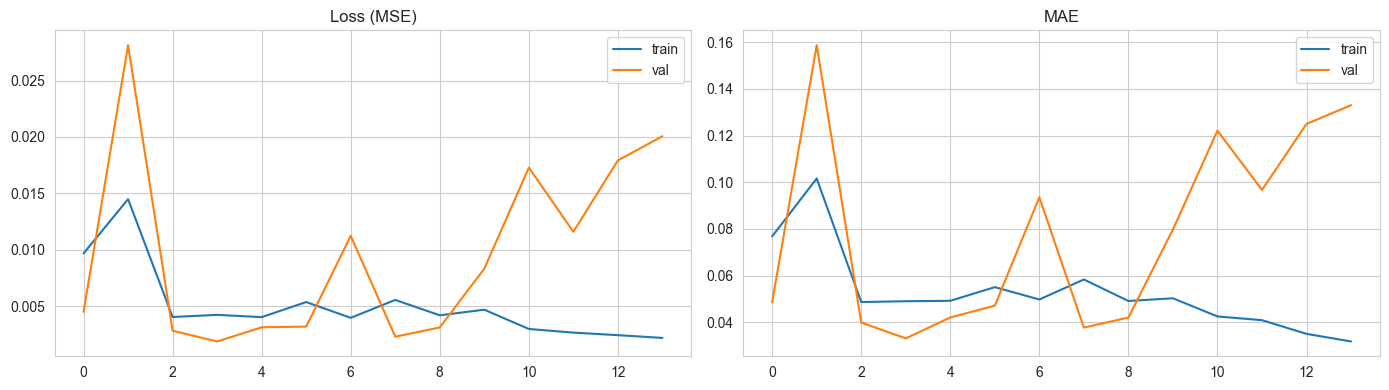

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss (MSE)')
axes[0].legend()

axes[1].plot(history.history['mae'], label='train')
axes[1].plot(history.history['val_mae'], label='val')
axes[1].set_title('MAE')
axes[1].legend()
plt.tight_layout()
plt.show()

## 6. Avaliação

In [ ]:
y_pred_scaled = model.predict(X_test).flatten()
y_pred = inverse_transform(y_pred_scaled, scaler)
y_true = inverse_transform(y_test, scaler)

metrics = compute_metrics(y_true, y_pred)
print_metrics(metrics)

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step

📊 MÉTRICAS DE AVALIAÇÃO
  MAE  : 4.7842
  RMSE : 6.2173
  MAPE : 2.58%



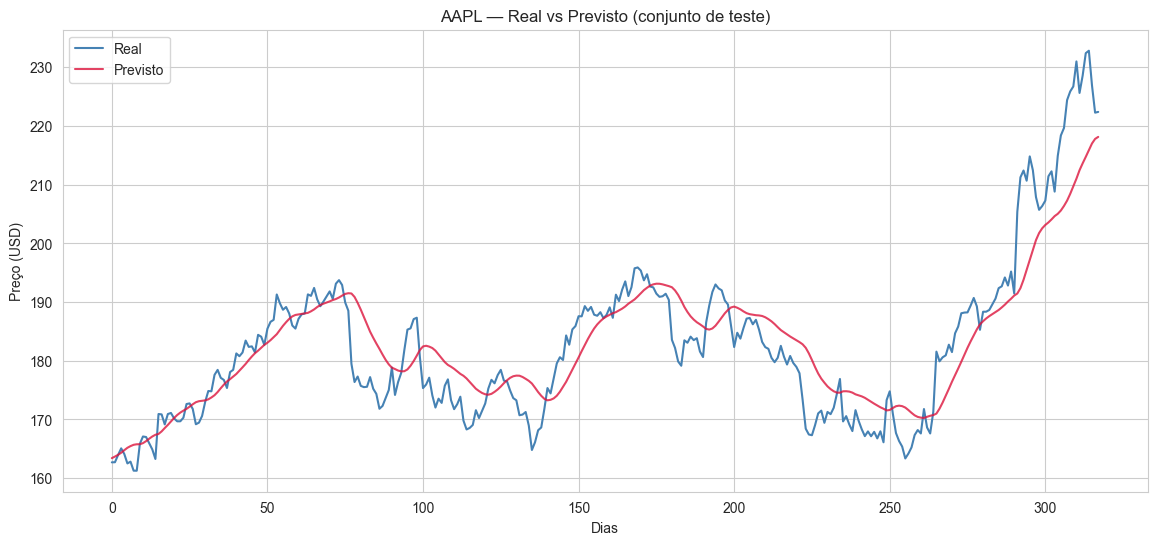

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(y_true, label='Real', color='steelblue')
plt.plot(y_pred, label='Previsto', color='crimson', alpha=0.8)
plt.title(f'{SYMBOL} — Real vs Previsto (conjunto de teste)')
plt.xlabel('Dias')
plt.ylabel('Preço (USD)')
plt.legend()
plt.show()

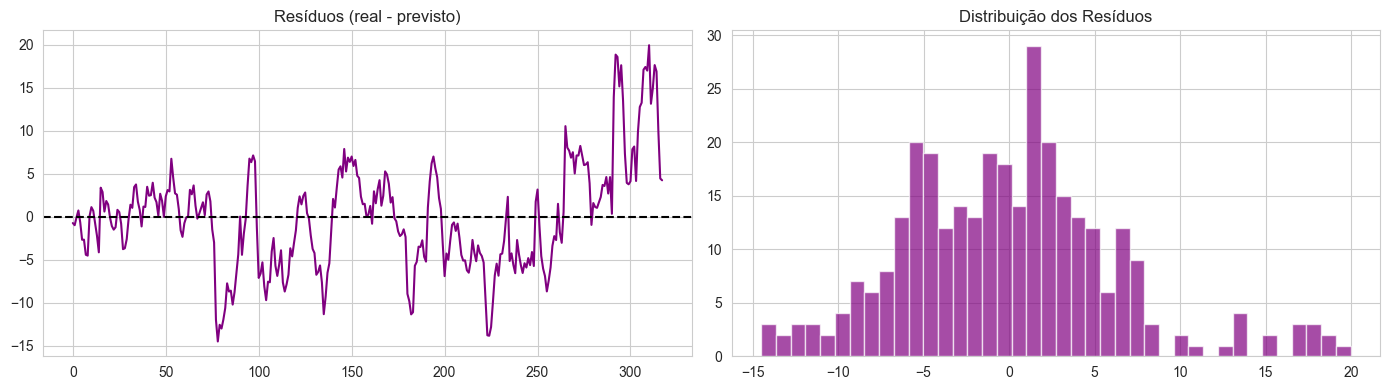

In [ ]:
errors = y_true - y_pred
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(errors, color='purple')
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title('Resíduos (real - previsto)')

axes[1].hist(errors, bins=40, color='purple', alpha=0.7)
axes[1].set_title('Distribuição dos Resíduos')
plt.tight_layout()
plt.show()

## 7. Salvamento dos artefatos

In [ ]:
from datetime import datetime, timezone

MODELS_DIR = PROJECT_ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)

model_path = MODELS_DIR / 'lstm_model.keras'
scaler_path = MODELS_DIR / 'scaler.pkl'
metadata_path = MODELS_DIR / 'metadata.json'

model.save(model_path)
save_scaler(scaler, str(scaler_path))

metadata = {
    'symbol': SYMBOL,
    'start_date': START_DATE,
    'end_date': END_DATE,
    'window_size': WINDOW_SIZE,
    'lstm_units_1': 64,
    'lstm_units_2': 64,
    'dropout_rate': 0.2,
    'epochs_trained': len(history.history['loss']),
    'batch_size': 32,
    'learning_rate': 0.001,
    'train_samples': int(X_train.shape[0]),
    'test_samples': int(X_test.shape[0]),
    'metrics': metrics,
    'trained_at': datetime.now(timezone.utc).isoformat(),
}

with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f'✅ Modelo salvo em: {model_path}')
print(f'✅ Scaler salvo em: {scaler_path}')
print(f'✅ Metadata salvo em: {metadata_path}')

✅ Modelo salvo em: C:\Users\Dione\Desktop\tech-challenge-fase4\tech-challenge-fase4\models\lstm_model.keras
✅ Scaler salvo em: C:\Users\Dione\Desktop\tech-challenge-fase4\tech-challenge-fase4\models\scaler.pkl
✅ Metadata salvo em: C:\Users\Dione\Desktop\tech-challenge-fase4\tech-challenge-fase4\models\metadata.json


## 8. Próximos passos

Com os artefatos salvos, a API FastAPI em `src/api/main.py` consegue carregá-los
automaticamente no startup. Para testar:

```bash
uvicorn src.api.main:app --reload
# Acesse http://localhost:8000/docs
```

Ou via Docker Compose com Prometheus + Grafana:

```bash
docker-compose up -d
```